In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **Project Name**    - **Amazon Prime Video**




##### **Project Type**    - Content Strategy Analysis for Prime Video
##### **Contribution**    - Individual
##### **Name -** - sanjit



# **Project Summary -**

Amazon Prime Video is a leading global streaming platform offering a vast library of movies and TV shows. In the highly competitive streaming industry, data-driven insights are essential for understanding audience preferences, optimizing content strategies, and driving user engagement.

This project focuses on analyzing a dataset containing over 9,000 titles and 124,000 cast/crew credits available on Amazon Prime Video (U.S. region). By exploring various attributes such as genre, release year, age certification, ratings (IMDb, TMDB), and production countries, the project aims to uncover trends and patterns in the platform’s content library.

The primary objective is to understand content diversity, regional production patterns, and how various features like runtime, popularity, and ratings relate to one another. Such insights can support better content acquisition strategies, improve recommendation systems, and enhance the overall viewer experience.

Through visual storytelling and exploratory data analysis (EDA), this project provides valuable information that can benefit content managers, data analysts, and business decision-makers in the streaming domain.

#### **Define Your Business Objective?**

To improve content strategy and user engagement by analyzing factors like genre, release year, runtime, popularity, and ratings. This helps in making data-driven decisions to find high-performing content, expand variety, and invest better in original and licensed content.

# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [2]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Dataset Loading

In [3]:
# Load Dataset
from google.colab import drive
drive.mount('/content/drive')




Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:

df = pd.read_csv('/content/drive/MyDrive/pandaswork/titles.csv/titles.csv')

In [5]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

### Dataset First View

In [6]:
# Dataset First Look
df.head()

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
0,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],26.0,tt0850645,8.6,1092.0,15.424,7.6
1,tm19248,The General,MOVIE,"During America’s Civil War, Union spies steal ...",1926,NaN,78,"['action', 'drama', 'war', 'western', 'comedy'...",['US'],NaN,tt0017925,8.2,89766.0,8.647,8.0
2,tm82253,The Best Years of Our Lives,MOVIE,It's the hope that sustains the spirit of ever...,1946,NaN,171,"['romance', 'war', 'drama']",['US'],NaN,tt0036868,8.1,63026.0,8.435,7.8
3,tm83884,His Girl Friday,MOVIE,"Hildy, the journalist former wife of newspaper...",1940,NaN,92,"['comedy', 'drama', 'romance']",['US'],NaN,tt0032599,7.8,57835.0,11.270,7.4
4,tm56584,In a Lonely Place,MOVIE,An aspiring actress begins to suspect that her...,1950,NaN,94,"['thriller', 'drama', 'romance']",['US'],NaN,tt0042593,7.9,30924.0,8.273,7.6


### Dataset Rows & Columns count

In [7]:
# Dataset Rows & Columns count
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9871 entries, 0 to 9870
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    9871 non-null   object 
 1   title                 9871 non-null   object 
 2   type                  9871 non-null   object 
 3   description           9752 non-null   object 
 4   release_year          9871 non-null   int64  
 5   age_certification     3384 non-null   object 
 6   runtime               9871 non-null   int64  
 7   genres                9871 non-null   object 
 8   production_countries  9871 non-null   object 
 9   seasons               1357 non-null   float64
 10  imdb_id               9204 non-null   object 
 11  imdb_score            8850 non-null   float64
 12  imdb_votes            8840 non-null   float64
 13  tmdb_popularity       9324 non-null   float64
 14  tmdb_score            7789 non-null   float64
dtypes: float64(5), int64(

### Dataset Information

In [8]:
# Dataset Info
#9871 rows and 15 columns


## **Data** **Wrangling**


#### Duplicate Values

In [9]:
# Dataset Duplicate Value Count
df.duplicated().sum()


np.int64(3)

In [10]:
dublicated_rows =df[df.duplicated()]
dublicated_rows

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
480,tm89134,The Gunman From Bodie,MOVIE,The Rough Riders are after a gang of rustlers....,1941,NaN,62,['western'],['US'],NaN,tt0033683,5.9,133.0,0.991,7.0
720,tm66674,Dynamite,MOVIE,Two members of a dynamite crew--a rugged veter...,1949,NaN,68,"['drama', 'crime']",['US'],NaN,tt0039343,5.0,24.0,0.841,NaN
722,tm137955,Broken Dreams,MOVIE,Medical intern Robert Morley is distraught aft...,1933,NaN,68,"['drama', 'romance']",['US'],NaN,tt0023849,5.8,74.0,0.600,NaN


In [11]:
df[df['id'] == 'tm137955']

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
719,tm137955,Broken Dreams,MOVIE,Medical intern Robert Morley is distraught aft...,1933,NaN,68,"['drama', 'romance']",['US'],NaN,tt0023849,5.8,74.0,0.6,NaN
722,tm137955,Broken Dreams,MOVIE,Medical intern Robert Morley is distraught aft...,1933,NaN,68,"['drama', 'romance']",['US'],NaN,tt0023849,5.8,74.0,0.6,NaN


In [12]:
df.drop_duplicates(inplace=True, keep='first')
df.duplicated().sum()

np.int64(0)

#### Missing Values/Null Values

In [13]:
# Missing Values/Null Values Count
df.isnull().mean()*100

,0
id,0.000000
title,0.000000
type,0.000000
description,1.205918
release_year,0.000000
age_certification,65.707337
runtime,0.000000
genres,0.000000
production_countries,0.000000
seasons,86.248480


In [14]:
# Visualizing the missing values
#tmdb_popularity,imdb_votes,tmdb_score,imdb_score = filling median value in these
#imdb_id,seasons,age_certification,description = droping these columns subset because the % of null value is grater or very less
df_visualizing_null = (df.isnull().mean()*100).sort_values(ascending=False)
df_visualizing_null

,0
seasons,86.248480
age_certification,65.707337
tmdb_score,21.078233
imdb_votes,10.447912
imdb_score,10.346575
imdb_id,6.759222
tmdb_popularity,5.543170
description,1.205918
runtime,0.000000
title,0.000000


In [15]:
df.dropna(subset =['imdb_id'],inplace = True)

In [16]:
df['description'].fillna("No description available",inplace=True)
df['age_certification'].replace("N/A", np.nan, inplace=True)

df['seasons'].replace('N/A',np.nan, inplace=True)

/tmp/ipykernel_7410/3340904965.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['description'].fillna("No description available",inplace=True)
/tmp/ipykernel_7410/3340904965.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inp

**So, in above code i filled the null value with something that is written in the code. In (age_certification and description) data may be not available so replacing the null value is good option
as in droping we can loose lots of data**


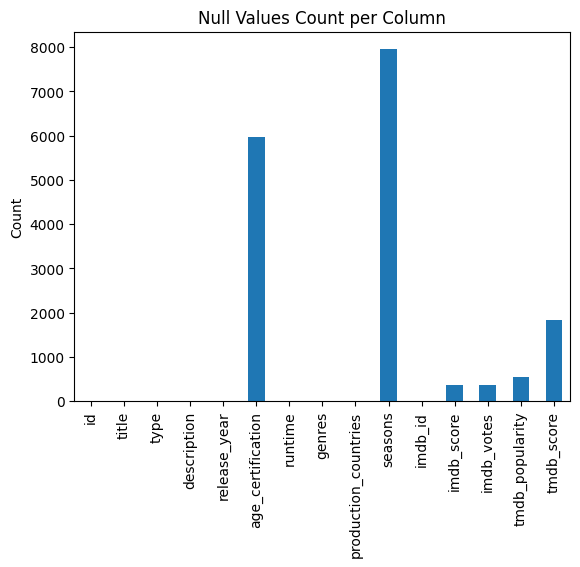

In [17]:
df.isnull().sum().plot(kind='bar')
plt.title("Null Values Count per Column")
plt.ylabel("Count")
plt.show()

*In these bar plot we can see the null value as par columns in decreasing order but we can ignore *



In [18]:
df[['tmdb_popular','tmdb_score','imdb_scoreity','imdb_votes']] = df[['tmdb_popularity','imdb_votes','tmdb_score','imdb_score']].fillna(df[['tmdb_popularity','imdb_votes','tmdb_score','imdb_score']].median())



**filled the null value with median as we can't drop thses data as the value of null is in higher side and for me filling with null value is good option rather then droping**






### What did you know about your dataset?



```
`# This is formatted as code`
```

So, these data set is from amazon prime video and we have 9871 rows and 15 columns such as id,title,imdb_rating,imdb_score etc.


## ***2. Understanding Your Variables***

In [19]:
# Dataset Columns
df.columns

Index(['id', 'title', 'type', 'description', 'release_year',
       'age_certification', 'runtime', 'genres', 'production_countries',
       'seasons', 'imdb_id', 'imdb_score', 'imdb_votes', 'tmdb_popularity',
       'tmdb_score', 'tmdb_popular', 'imdb_scoreity'],
      dtype='object')

In [20]:
# Dataset Describe
df.describe()

,release_year,runtime,seasons,imdb_score,imdb_votes,tmdb_popularity,tmdb_score,tmdb_popular,imdb_scoreity
count,9201.000000,9201.000000,1249.000000,8847.000000,9201.000000,8657.000000,9.201000e+03,9201.000000,9201.000000
mean,2000.623628,86.625693,2.884708,5.976534,5.981285,7.078035,8.217130e+03,6.816350,5.983763
std,26.297317,32.826648,4.062749,1.344028,1.318130,29.300767,4.503744e+04,28.440451,1.336848
min,1912.000000,1.000000,1.000000,1.100000,1.100000,0.000153,5.000000e+00,0.000153,0.800000
25%,1994.000000,67.000000,1.000000,5.100000,5.200000,1.322000,1.240000e+02,1.400000,5.400000
50%,2013.000000,90.000000,1.000000,6.100000,6.100000,2.652000,4.640000e+02,2.652000,6.000000
75%,2018.000000,103.000000,3.000000,6.900000,6.900000,5.861000,2.080000e+03,5.505000,6.700000
max,2022.000000,549.000000,49.000000,9.900000,9.900000,1437.906000,1.133692e+06,1437.906000,10.000000


### Variables Description

Answer Here

Variables Description

This data set was created to list all shows available on Amazon Prime streaming, and analyze the data to find interesting facts. This dataset has data available in the United States.

This dataset has two files containing the titles (titles.csv) and the cast (credits.csv) for the title.

This dataset contains +9k unique titles on Amazon Prime with 15 columns containing their information, including:

id: The title ID on JustWatch.

title: The name of the title.

show_type: TV show or movie.

description: A brief description.

release_year: The release year.

age_certification: The age certification.

runtime: The length of the episode (SHOW) or movie.

genres: A list of genres.

production_countries: A list of countries that produced the title.

seasons: Number of seasons if it's a SHOW.

imdb_id: The title ID on IMDB.

imdb_score: Score on IMDB.

imdb_votes: Votes on IMDB.

tmdb_popularity: Popularity on TMDB.

tmdb_score: Score on TMDB.

And over +124k credits of actors and directors on Amazon Prime titles with 5 columns containing their information:

person_ID: The person ID on JustWatch.

id: The title ID on JustWatch.

name: The actor or director's name.

character_name: The character name.

role: ACTOR or DIRECTOR.


### Check Unique Values for each variable.

In [21]:
# Check Unique Values for each variable by getting the count of unique values per column.
df[['id', 'title', 'type', 'description', 'release_year',
       'age_certification', 'runtime', 'genres', 'production_countries',
       'seasons', 'imdb_id', 'imdb_score', 'imdb_votes', 'tmdb_popularity',
       'tmdb_score']].nunique().sort_values(ascending=False)

,0
id,9201
imdb_id,9201
description,9092
title,9088
tmdb_popularity,5160
tmdb_score,3650
genres,2024
production_countries,486
runtime,203
release_year,110


In [22]:
def basic_clean(text):
  return str(text).lower().strip()

In [23]:
df['title'] = df['title'].apply(basic_clean)

In [24]:
def clean_text(text):
    if pd.isna(text):
        return ""
    text = text.lower()                     # Lowercase
    text = text.strip()                     # Strip outer whitespace
    text = text.replace('!', '').replace('#', '')  # Remove specific symbols
    for char in ['@', '$', '%', '^', '&', '*', '(', ')', '-', '_', '=', '+', '[', ']', '{', '}', '|', ':', ';', '"', "'", '<', '>', ',', '.', '?', '/','\\','[]']:
        text = text.replace(char, '')
    return ''.join([i for i in text if not i.isdigit()] )

In [25]:
#Dealing with string and white space

df['description'] = df['description'].apply(clean_text)
df['genres'] = df['genres'].apply(clean_text)
df['production_countries'] = df['production_countries'].apply(clean_text)
df['genres'].replace('[]', np.nan, inplace=True)
df['production_countries'].replace('[]', np.nan, inplace=True)
df['production_countries'].replace("['XX']", np.nan, inplace=True)
df['genres'].fillna('Unknown', inplace=True)
df['production_countries'].fillna('Unknown', inplace=True)
cols =['imdb_score','tmdb_popularity']
df[cols] = df[cols].apply(lambda x: x.fillna(x.median()))
# Convert 'tmdb_popular' column to integer type to remove decimal values
df['tmdb_score'] = df['tmdb_score'].astype(int)

/tmp/ipykernel_7410/844784539.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['genres'].replace('[]', np.nan, inplace=True)
/tmp/ipykernel_7410/844784539.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

In [26]:
df.to_csv('/content/drive/MyDrive/pandaswork prime video cleaned data.csv')

# **data cleaning of 2nd csv file**

In [27]:
df2 = pd.read_csv('/content/drive/MyDrive/pandaswork/credits.csv/credits.csv')

In [28]:
print(df2.columns)

Index(['person_id', 'id', 'name', 'character', 'role'], dtype='object')


In [29]:
df2.head()

,person_id,id,name,character,role
0,59401,ts20945,Joe Besser,Joe,ACTOR
1,31460,ts20945,Moe Howard,Moe,ACTOR
2,31461,ts20945,Larry Fine,Larry,ACTOR
3,21174,tm19248,Buster Keaton,Johnny Gray,ACTOR
4,28713,tm19248,Marion Mack,Annabelle Lee,ACTOR


In [30]:
df2.tail()

,person_id,id,name,character,role
124230,1938589,tm1054116,Sangam Shukla,Madhav,ACTOR
124231,1938565,tm1054116,Vijay Thakur,Sanjay Thakur,ACTOR
124232,728899,tm1054116,Vanya Wellens,Budhiya,ACTOR
124233,1938620,tm1054116,Vishwa Bhanu,Gissu,ACTOR
124234,1938620,tm1054116,Vishwa Bhanu,NaN,DIRECTOR


In [31]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 124235 entries, 0 to 124234
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   person_id  124235 non-null  int64 
 1   id         124235 non-null  object
 2   name       124235 non-null  object
 3   character  107948 non-null  object
 4   role       124235 non-null  object
dtypes: int64(1), object(4)
memory usage: 4.7+ MB


In [32]:
df2.describe()

,person_id
count,1.242350e+05
mean,4.064737e+05
std,5.616296e+05
min,1.000000e+00
25%,3.899200e+04
50%,1.339490e+05
75%,5.712560e+05
max,2.371153e+06


In [33]:
df2.isnull().mean()*100

,0
person_id,0.000000
id,0.000000
name,0.000000
character,13.109832
role,0.000000


In [34]:
df2['character'].fillna('Not_Available', inplace=True)

/tmp/ipykernel_7410/3513033744.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df2['character'].fillna('Not_Available', inplace=True)


In [35]:
df2['character'].replace({'Not_Available' : 'Not Available'}, inplace=True)

In [36]:
df2.duplicated().sum()

np.int64(56)

In [37]:
df2_dublicate = df2[df2.duplicated()]


In [38]:
df2 = df2.drop_duplicates()

In [39]:
def basic_clean(text):
  return str(text).lower().strip()


In [40]:
# Identify the columns that are strings and need cleaning
string_cols_to_clean = ['id', 'name', 'character', 'role']

# Apply the basic_clean function to each of these columns individually
for col in string_cols_to_clean:
    df2[col] = df2[col].apply(basic_clean)

In [41]:
def clean_text(text):
    if pd.isna(text):
        return ""
    text = text.lower()                     # Lowercase
    text = text.strip()                     # Strip outer whitespace
    text = text.replace('!', '').replace('#', '')  # Remove specific symbols
    for char in ['@', '$', '%', '^', '&', '*', '(', ')', '-', '_', '=', '+', '[', ']', '{', '}', '|', ':', ';', '"', "'", '<', '>', ',', '.', '?', '/','\\','[]']:
        text = text.replace(char, '')
    return ''.join([i for i in text if not i.isdigit()] )

In [42]:
df2['name'] = df2['name'].apply(clean_text)

In [43]:
df2['character'] = df2['character'].apply(clean_text)


In [44]:
df2['role'] = df2['role'].apply(clean_text)

In [45]:
df2.isnull().sum()

,0
person_id,0
id,0
name,0
character,0
role,0


In [46]:

df2['role'].unique()

array(['actor', 'director'], dtype=object)

In [47]:
df2.to_csv('/content/drive/MyDrive/pandaswork prime video cleaned credits.csv')

In [48]:
df = pd.read_csv('/content/drive/MyDrive/pandaswork prime video cleaned data.csv')



In [49]:
df2.head()

,person_id,id,name,character,role
0,59401,ts20945,joe besser,joe,actor
1,31460,ts20945,moe howard,moe,actor
2,31461,ts20945,larry fine,larry,actor
3,21174,tm19248,buster keaton,johnny gray,actor
4,28713,tm19248,marion mack,annabelle lee,actor


### What all manipulations have you done and insights you found?

Answer Here. filled the null value with median and with text ,droped duplicated value,cleaned special character and white space

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1 Univirate Anylasis


In [50]:
df.drop(columns=['Unnamed: 0'], inplace=True)

In [51]:
#dataset columns
print(df.columns)

Index(['id', 'title', 'type', 'description', 'release_year',
       'age_certification', 'runtime', 'genres', 'production_countries',
       'seasons', 'imdb_id', 'imdb_score', 'imdb_votes', 'tmdb_popularity',
       'tmdb_score', 'tmdb_popular', 'imdb_scoreity'],
      dtype='object')


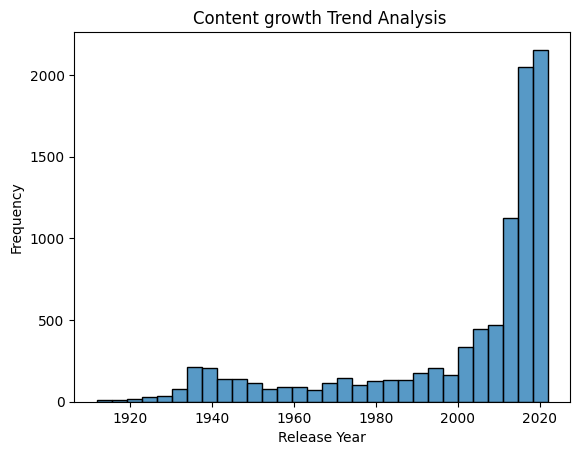

In [52]:
# Chart - 1 visualization code
#Histplot
sns.histplot(data=df,x='release_year',bins = 30)
plt.title('Content growth Trend Analysis ')
plt.xlabel('Release Year')
plt.ylabel('Frequency')
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here. Because histplot is used for Univriate analysis of numerical columns

##### 2. What is/are the insight(s) found from the chart?

### Insight:
Content production has increased significantly, with rapid growth observed after 2010.

### Interpretation:
This reflects an aggressive expansion strategy driven by rising competition in the OTT market.

### Implication:
Rapid growth in content volume may lead to saturation if not supported by consistent quality.

### Recommendation:
Shift focus from quantity to quality by prioritizing high-performing content over volume expansion.

#### Chart - 2

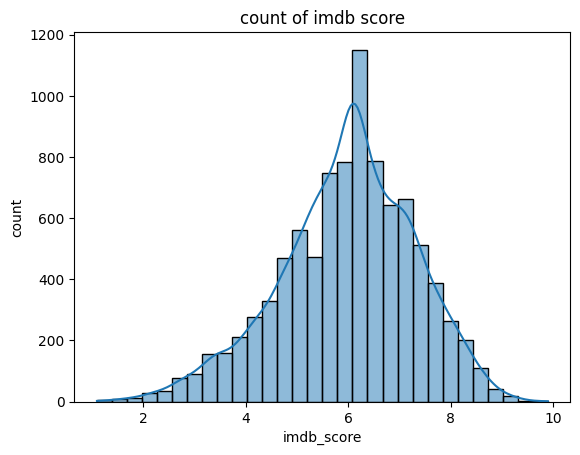

In [53]:
# Chart - 2 visualization code
#histplot

sns.histplot(df['imdb_score'],bins = 30, kde=True)
plt.title('count of imdb score')
plt.xlabel('imdb_score')
plt.ylabel('count')
plt.show()

##### 1. Why did you pick the specific chart?

Because histplot is used for Univriate analysis of numerical columns and Shows distribution shape.


##### 2. What is/are the insight(s) found from the chart?

### Insight:
Most content is concentrated in the mid-rating range (5–7), with relatively fewer high-rated titles above 8.

### Interpretation:
The platform contains a large volume of average-quality content, with limited presence of standout, high-quality titles.

### Implication:
A catalog dominated by mid-tier content may fail to strongly engage users or create differentiation, leading to reduced user satisfaction.

### Recommendation:
Prioritize acquisition and production of high-rated content to improve overall quality perception and user engagement.


**CHART 3**

In [75]:
yearly_data = df.groupby('release_year').agg({
    'imdb_score': 'mean',     # average rating per year
    'title': 'count'          # number of titles per year
}).reset_index()

yearly_data.rename(columns={'title': 'content_count'}, inplace=True)

In [69]:
print(yearly_data.head())

   release_year  imdb_score  content_count
0          1912        5.80              1
1          1914        5.60              2
2          1915        6.14              5
3          1916        7.05              2
4          1917        6.30              1


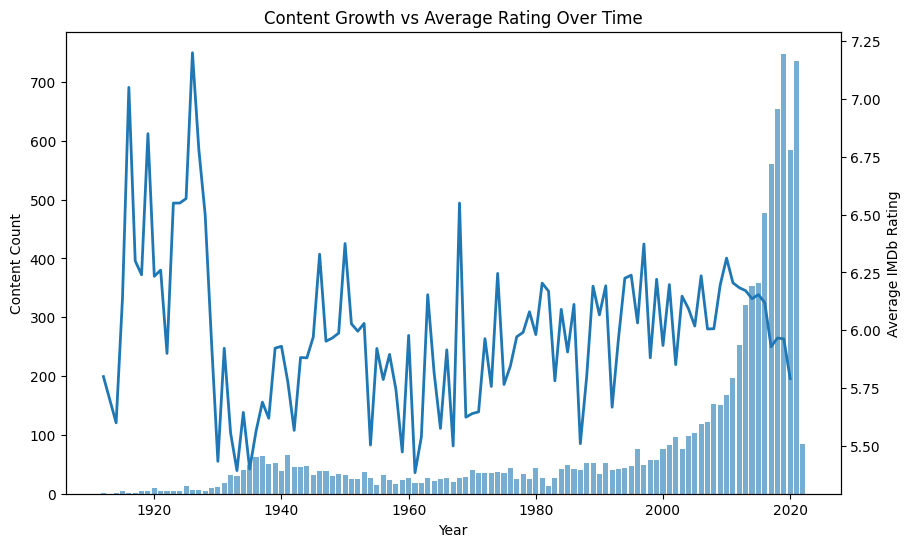

In [77]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(10,6))

# Content count (bars)
ax1.bar(yearly_data['release_year'], yearly_data['content_count'], alpha=0.6)
ax1.set_xlabel('Year')
ax1.set_ylabel('Content Count')

yearly_data = yearly_data[yearly_data['release_year'] < 2021]

# Rating (line)
ax2 = ax1.twinx()
ax2.plot(yearly_data['release_year'], yearly_data['imdb_score'], linewidth=2)
ax2.set_ylabel('Average IMDb Rating')

plt.title('Content Growth vs Average Rating Over Time')
plt.show()

##### 1. Why did you pick the specific chart?
for showing trend over time line chart are compatable on avg imdb score over year and  bar is compatable on year trends


##### 2. What is/are the insight(s) found from the chart?

### Insight:
Content production has increased sharply over time, especially after 2010, while average IMDb ratings have remained relatively stable or slightly declined.

### Interpretation:
The rapid expansion in content volume has not resulted in improved content quality.

### Implication:
A volume-driven strategy is leading to content saturation without enhancing user satisfaction or differentiation.

### Recommendation:
Shift focus toward producing fewer, higher-quality titles rather than aggressively expanding the content library.

**CHART 4**

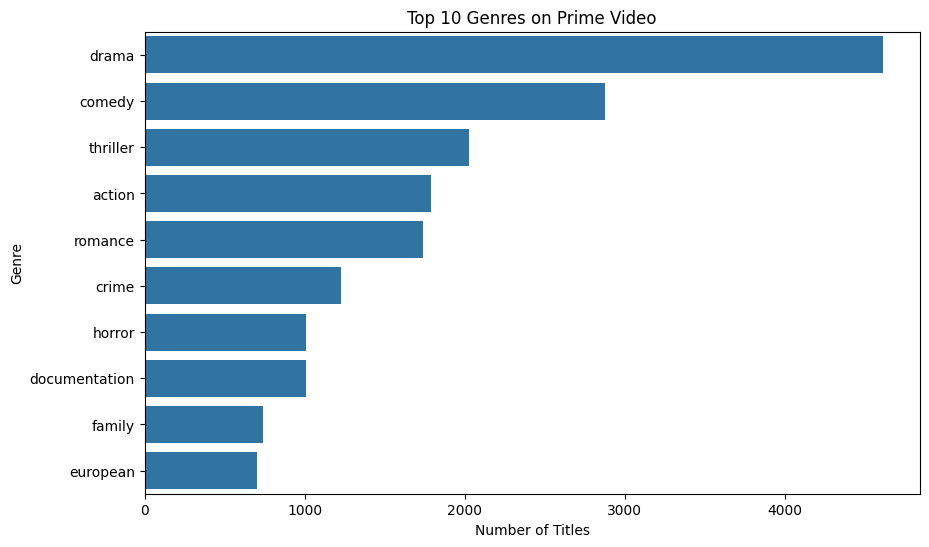

In [86]:
# Flatten
genre_data = genre_data.explode()

# Count
top_genres = genre_data.value_counts().head(10)

# Plot
plt.figure(figsize=(10,6))
sns.barplot(x=top_genres.values, y=top_genres.index)

plt.title('Top 10 Genres on Prime Video')
plt.xlabel('Number of Titles')
plt.ylabel('Genre')

plt.show()
plt.show()

##### 1. Why did you pick the specific chart?

so we are comparing categorical data and for this data barplot is compatible for that

##### 2. What is/are the insight(s) found from the chart?

### Insight:
The content catalog is heavily concentrated in a few dominant genres, particularly Drama and Comedy.

### Interpretation:
Prime Videos content strategy appears skewed toward popular, broad-appeal genres rather than a balanced portfolio.

### Implication:
High concentration in limited genres increases the risk of content saturation, reducing novelty and long-term user engagement.

### Recommendation:
Diversify content by investing in underrepresented genres such as documentary, family, and niche categories to improve audience reach and engagement.

**CHART 5**

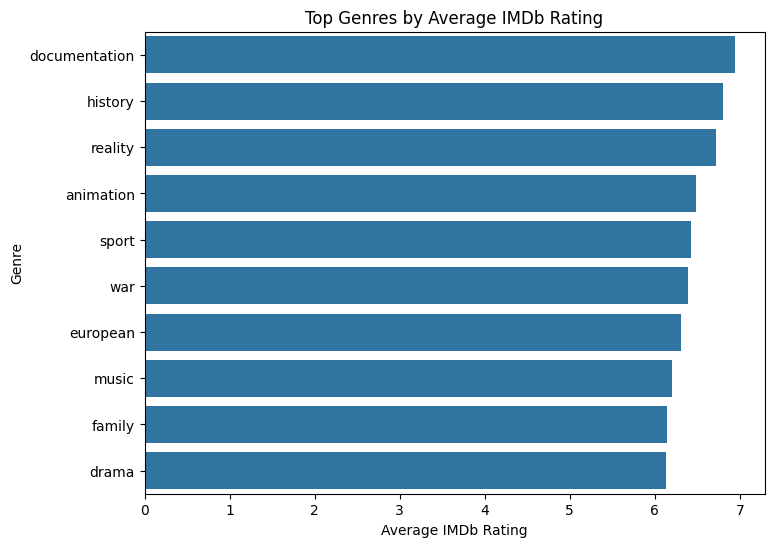

In [94]:
genre_data['genres'] = genre_data['genres'].str.lower().str.strip().str.split()
genre_data = genre_data.explode('genres')

# Group by genre and calculate average rating
genre_rating = genre_data.groupby('genres')['imdb_score'].mean().sort_values(ascending=False)

# Take top 10 genres by rating
top_genre_rating = genre_rating.head(10)

# Plot
plt.figure(figsize=(8,6))
sns.barplot(x=top_genre_rating.values, y=top_genre_rating.index)

plt.title('Top Genres by Average IMDb Rating')
plt.xlabel('Average IMDb Rating')
plt.ylabel('Genre')

plt.show()

In [93]:
genre_data['genres'].value_counts().head(10)

,count
genres,
drama,4612
comedy,2880
thriller,2029
action,1788
romance,1739
crime,1230
horror,1008
documentation,1006
family,743



1. Why did you pick the specific chart?

because it is used for comparing categorical data

##### 2. What is/are the insight(s) found from the chart?

### Insight:
Several genres such as documentary, history, and animation achieve higher average ratings compared to high-volume genres like drama and comedy.

### Interpretation:
Content production is concentrated in popular genres, but these do not necessarily deliver the highest quality or user satisfaction.

### Implication:
There is a mismatch between content investment and performance, where high-performing genres are underrepresented in the catalog.

### Recommendation:
Reallocate content strategy to increase investment in high-performing genres while maintaining a balanced portfolio.

#### Chart - 6

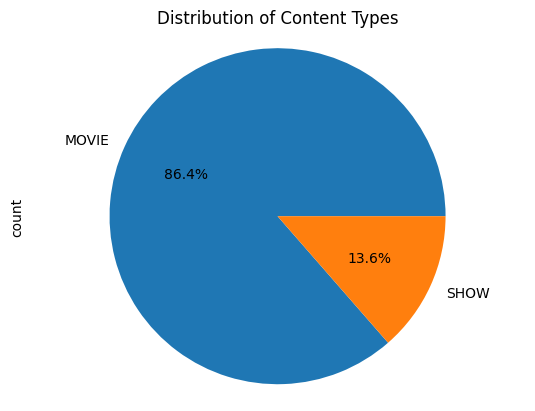

In [54]:
# Chart - 6 visualization code
# Pie chart
df['type'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Distribution of Content Types')
plt.axis('equal')
plt.show()

##### 1. Why did you pick the specific chart?

because A pie chart is ideal when you want to compare proportions of categorical univariate

 in this case, the proportion of Movies vs TV Shows on Amazon Prime.

##### 2. What is/are the insight(s) found from the chart?


### Insights:
The platform is heavily dominated by movies (86%), with a significantly smaller share of TV shows (14%), indicating an imbalanced content strategy.

#### Chart - 7

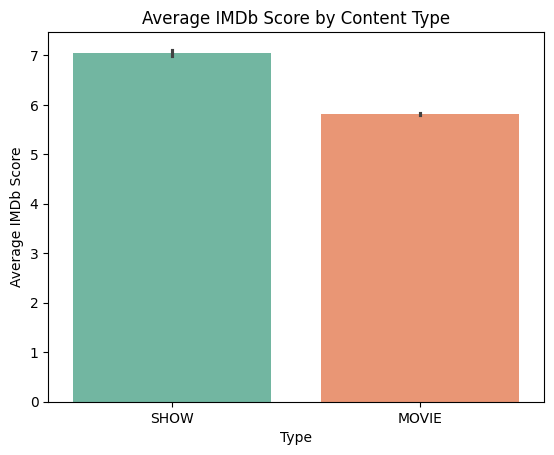

In [56]:
# Chart - 7 visualization code
#barplot

sns.barplot(data=df, x='type', y='imdb_score', estimator='mean', hue='type', palette='Set2', legend=False)
plt.title("Average IMDb Score by Content Type")
plt.xlabel("Type")
plt.ylabel("Average IMDb Score")
plt.show()

##### 1. Why did you pick the specific chart?

A bar plot is ideal for showing comparative statistics, like mean IMDb scores across categories.(continous V/S categorical)

##### 2. What is/are the insight(s) found from the chart?

### Insight:
TV shows have significantly higher average IMDb ratings compared to movies.

### Interpretation:
Series-based content tends to deliver better audience satisfaction and sustained engagement than one-time movie content.

### Implication:
The current content strategy is heavily skewed toward movies despite shows demonstrating stronger performance.

### Recommendation:
Increase investment in TV shows to improve overall platform quality and user retention.

#### Chart - 8

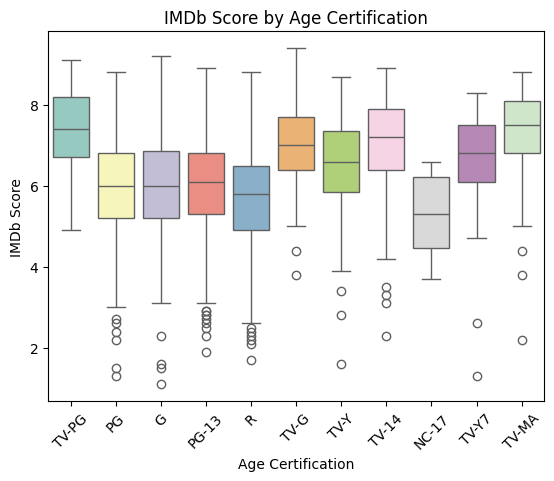

In [57]:
# Chart - 8 visualization code
# box plot
sns.boxplot(x='age_certification', y='imdb_score', data=df, hue='age_certification', palette='Set3', legend = False)
plt.title('IMDb Score by Age Certification')
plt.xlabel('Age Certification')
plt.ylabel('IMDb Score')
plt.xticks(rotation=45)
plt.show()

##### 1. Why did you pick the specific chart?

It shows the clear distribution how IMDb scores vary across different age certifications (like G, PG, PG-13, R, etc.).
and it best for compare between continous vs categorical columns

##### 2. What is/are the insight(s) found from the chart?

### Insight:
Content with mature age certifications (TV-MA, TV-14) tends to have higher median IMDb ratings compared to general audience categories (G, PG).

### Interpretation:
Content targeting adult audiences often involves more complex storytelling and themes, which may contribute to higher audience ratings.

### Implication:
Focusing primarily on family-friendly content may limit overall content quality perception on the platform.

### Recommendation:
Balance content strategy by increasing investment in mature audience content while maintaining a diverse portfolio.

#### Chart - 9

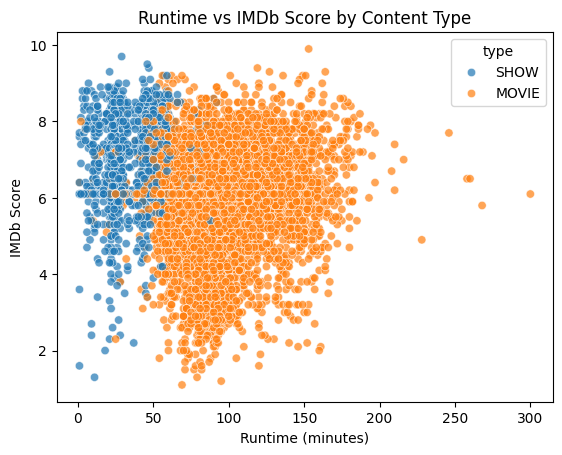

In [59]:
# Chart - 9 visualization code
# Filter the DataFrame for runtime up to 300 minutes
df_filtered_runtime = df[df['runtime'] <= 300]

sns.scatterplot(x='runtime', y='imdb_score', hue='type', data=df_filtered_runtime, alpha=0.7)
plt.title('Runtime vs IMDb Score by Content Type')
plt.xlabel('Runtime (minutes)')
plt.ylabel('IMDb Score')
plt.show()

##### 1. Why did you pick the specific chart?

It’s ideal for examining the relationship between two continuous variables, in this case, runtime and IMDb score.

##### 2. What is/are the insight(s) found from the chart?

### Insight:
TV shows are concentrated within a narrow runtime range and exhibit more consistent ratings, while movies span a wider runtime range with highly variable performance.

### Interpretation:
Content length does not strongly influence quality, particularly for movies, where longer runtime does not guarantee higher ratings.

### Implication:
Movies carry higher performance risk due to inconsistent quality, whereas TV shows provide more predictable user satisfaction.

### Recommendation:
Focus on structured, episodic content strategies rather than relying on longer-duration movies to drive engagement.


## Final Insights

* Content has increased a lot over time, but ratings stayed almost the same
 more content is not equalto better quality

* Movies dominate the platform (86%), but TV shows have higher average ratings (7 vs 5.8)

* Genres like Drama and Comedy have the most content, but not the highest ratings

* High-performing genres (Documentary, History) have less content → missed opportunity

* Mature content (TV-MA, TV-14) tends to perform better than general audience content

---

## Conclusion

Overall, the platform is focused more on quantity and popular categories, but better performance comes from TV shows, niche genres, and mature content.
